In [1]:
# SPDX-FileCopyrightText: 2025 Contributors to the OpenSTEF project <openstef@lfenergy.org>
#
# SPDX-License-Identifier: MPL-2.0

In [2]:
# Configure the notebook runtime and logging used by all workshop cells.
import logging
import os
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from openstef_beam.analysis.visualizations.grouped_target_metric_visualization import GroupedTargetMetricVisualization
from openstef_beam.analysis.visualizations.quantile_probability_visualization import QuantileProbabilityVisualization
from openstef_beam.analysis.visualizations.summary_table_visualization import SummaryTableVisualization
from openstef_beam.analysis.visualizations.windowed_metric_visualization import WindowedMetricVisualization

# Keep tutorial output focused on the workshop results.
warnings.filterwarnings("ignore")

# Limit numerical-library threads so model training stays responsive.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Configure the notebook renderer and log filters.
from openstef_core.testing import configure_notebook_display, load_liander_dataset, setup_notebook_logging

# Keep docs output static; set this to "notebook" for interactive plots locally.
NOTEBOOK_RENDERER = "png"
configure_notebook_display(renderer=NOTEBOOK_RENDERER)
logger = setup_notebook_logging(
    __name__,
    suppress=(
        "tqdm",
        "choreographer",
        "kaleido",
        "httpx",
        "huggingface_hub",
        "fsspec",
        "filelock",
        "openstef_core.datasets",
        "lightgbm",
    ),
)
logging.basicConfig(level=logging.WARNING, format="[%(asctime)s][%(levelname)s] %(message)s")

# OpenSTEF Workshop: Forecasting Energy for Solar Parks

This workshop follows one normalized solar park near Oosterwolde through a complete OpenSTEF workflow. We use the same target and forecast period while exploring the modular layers of OpenSTEF:

1. Explore real grid data: measurements, weather forecasts, profiles, and prices
2. Train and explain a default XGBoost model
3. Inspect the features created by preprocessing
4. Train GBLinear and learn when to trust each model with `openstef-meta`
5. Forecast with Chronos-2 through `openstef-foundation-models`
6. Compare the models with a short `openstef-beam` backtest

The point is to compare model behavior, not only to produce a score.

## Step 1 - Workshop Setup

We configure thread settings to keep the notebook responsive when model training and backtesting use parallel numerical libraries.


### 1.1 Download the Benchmark Dataset

Download the files for one target through `load_liander_dataset`. The loader also fetches the shared profiles and prices, then caches everything in its default `./liander_dataset` directory.


In [3]:
# Load the selected benchmark files and cache them locally.
# Define the target path used by the dataset loader.
DATASET_DIR = Path("./liander_dataset")
TARGET_GROUP = "solar_park"
TARGET_NAME = "Within 15 kilometers of Oosterwolde_normalized"
TARGET_PATH = f"{TARGET_GROUP}/{TARGET_NAME}"

# Download only the selected target and required metadata.
dataset = load_liander_dataset(target=TARGET_PATH, extra_files=["liander2024_targets.yaml"])

## Step 2 - Explore the Dataset

### 2.1 Meet Our Target: Solar Park near Oosterwolde

The target provider reads the benchmark metadata and target-specific files from the downloaded snapshot. We select one normalized solar park so every later comparison uses the same target.


In [4]:
# Select the solar-park target used throughout the workshop.
# Load target metadata from the benchmark snapshot.
from openstef_beam.benchmarking.benchmarks.liander2024 import Liander2024TargetProvider

target_provider = Liander2024TargetProvider(data_dir=DATASET_DIR)
# Resolve the named target for all later data requests.
targets = target_provider.get_targets()
target = next(item for item in targets if item.name == TARGET_NAME and item.group_name == TARGET_GROUP)

print(f"Target: {target.name}")
print(f"Location: ({target.latitude:.3f}°N, {target.longitude:.3f}°E)")
print(f"Description: {target.description}")
print(f"Category: {target.group_name}")
print(f"Capacity limits: {target.lower_limit:.3f} MW to {target.upper_limit:.3f} MW")
print(f"Training starts: {target.train_start.date()}")
print(f"Benchmark period: {target.benchmark_start.date()} to {target.benchmark_end.date()}")

Target: Within 15 kilometers of Oosterwolde_normalized
Location: (52.988°N, 6.295°E)
Description: Solar park within 15 kilometers of Oosterwolde (Normalized load)
Category: solar_park
Capacity limits: -0.853 MW to 0.003 MW
Training starts: 2024-02-01
Benchmark period: 2024-03-01 to 2024-12-31


### 2.2 Load Measurements

Active power is measured every 15 minutes. The measurements show the target's daily and weather-driven variability.


- **Q2.2.1** What daily, seasonal, and event-driven patterns can you see?
- **Q2.2.2** Which deviations look predictable from the inputs?
- **Q2.2.3** Where would a forecast error matter most operationally?

Shape: 32,160 rows x 1 columns
Period: 2024-02-01 00:00:00+00:00 to 2024-12-31 23:45:00+00:00
Columns: ['load']


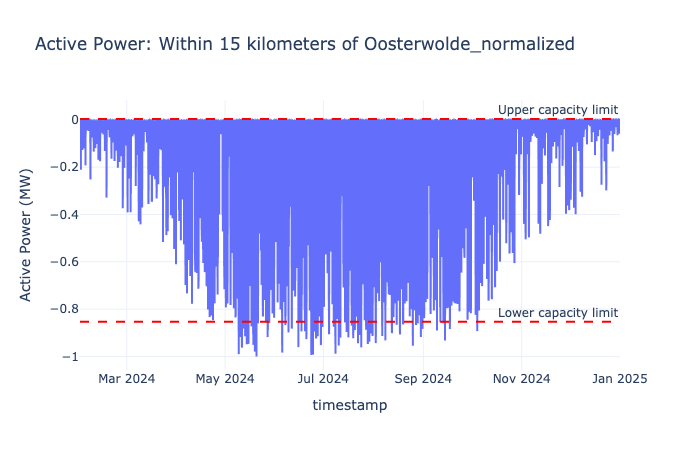

In [5]:
# Inspect the measured active-power signal and capacity limits.
# Load the target measurements and resolve their single version.
load_dataset = target_provider.get_measurements_for_target(target)
load_df = load_dataset.select_version().data

# Summarize the measurement coverage before plotting it.
print(f"Shape: {load_df.shape[0]:,} rows x {load_df.shape[1]} columns")
print(f"Period: {load_df.index.min()} to {load_df.index.max()}")
print(f"Columns: {list(load_df.columns)}")

# Plot the measurements with the target capacity limits.
fig = px.line(
    load_df,
    y="load",
    title=f"Active Power: {TARGET_NAME}",
    labels={"load": "Active Power (MW)", "index": "Time (UTC)"},
    template="plotly_white",
)
fig.add_hline(y=target.upper_limit, line_dash="dash", line_color="red", annotation_text="Upper capacity limit")
fig.add_hline(y=target.lower_limit, line_dash="dash", line_color="red", annotation_text="Lower capacity limit")
fig.update_layout(height=450, showlegend=False)
fig.show()

### 2.3 Weather Forecasts

Solar radiation drives PV generation, while temperature and wind provide additional context. These are versioned weather forecasts with an `available_at` timestamp, which prevents look-ahead bias during backtesting.


- **Q2.3.1** Which weather variable appears most connected to the solar signal?
- **Q2.3.2** Do the forecasts look smooth, noisy, or systematically delayed?
- **Q2.3.3** What would change if we used weather measurements instead of forecasts?

Shape: 35,229 rows x 11 columns
Weather features: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_speed_80m', 'wind_direction_10m', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'direct_normal_irradiance']


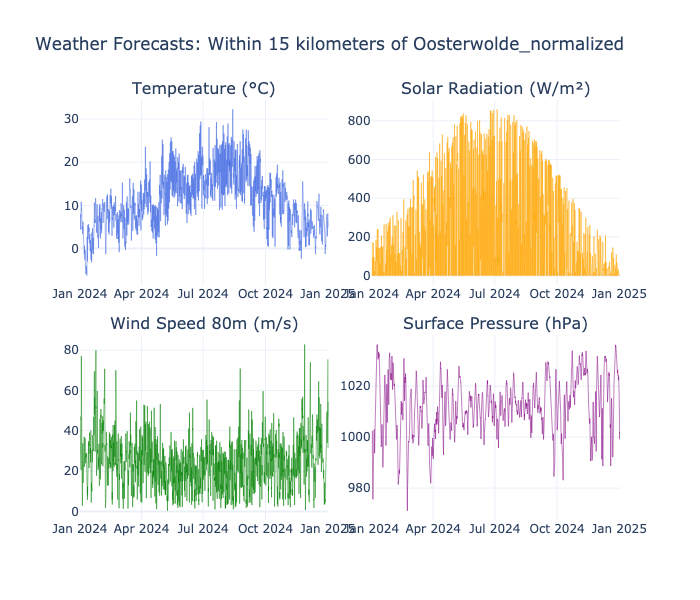

In [6]:
# Inspect the versioned weather features used by the forecasting models.
# Load weather forecasts and select the latest available version for exploration.
weather_dataset = target_provider.get_weather_for_target(target)
weather_df = weather_dataset.select_version().data

# Summarize the available weather features.
print(f"Shape: {weather_df.shape[0]:,} rows x {weather_df.shape[1]} columns")
print(f"Weather features: {list(weather_df.columns)}")

# Define the weather panels shown in the exploratory plot.
weather_columns = [
    ("temperature_2m", "Temperature (°C)", "royalblue"),
    ("shortwave_radiation", "Solar Radiation (W/m²)", "orange"),
    ("wind_speed_80m", "Wind Speed 80m (m/s)", "green"),
    ("surface_pressure", "Surface Pressure (hPa)", "purple"),
]
# Plot the main weather drivers side by side.
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[label for _, label, _ in weather_columns],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)
for index, (column, label, color) in enumerate(weather_columns):
    row, column_index = divmod(index, 2)
    fig.add_trace(
        go.Scatter(
            x=weather_df.index,
            y=weather_df[column],
            name=label,
            line={"color": color, "width": 0.5},
            showlegend=False,
        ),
        row=row + 1,
        col=column_index + 1,
    )
fig.update_layout(title=f"Weather Forecasts: {TARGET_NAME}", height=600, template="plotly_white")
fig.show()

### 2.4 Standard Load Profiles

Profiles capture recurring patterns and show how OpenSTEF can combine target-specific data with reusable contextual features.


- **Q2.4.1** What repeating patterns are visible in the two-week window?
- **Q2.4.2** Why could a shared profile help when the target's own history is incomplete?
- **Q2.4.3** Which assumption about the relationship between profile and target should we test?

Profile columns: ['E1A_AZI_A', 'E1A_AMI_A', 'E1B_AZI_A', 'E1B_AMI_A', 'E1C_AZI_A', 'E1C_AMI_A', 'E2A_AZI_A', 'E2A_AMI_A', 'E2B_AZI_A', 'E2B_AMI_A', 'E3A_A', 'E3B_A', 'E3C_A', 'E3D_A', 'E4A_A']


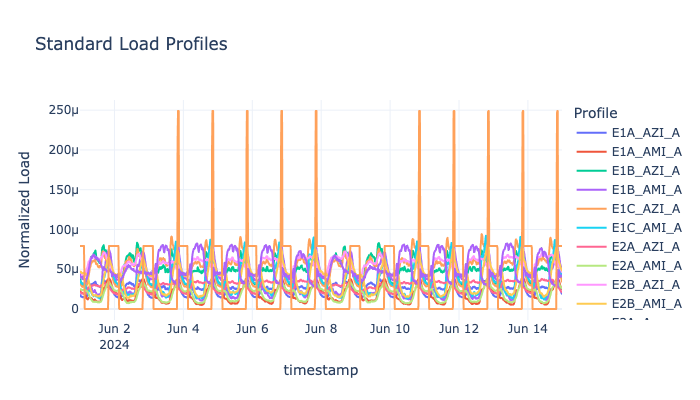

In [7]:
# Inspect recurring profile features that can provide additional context.
# Load the shared profiles and select the demonstration window.
profiles_dataset = target_provider.get_profiles()
profiles_df = profiles_dataset.select_version().data.loc["2024-06-01":"2024-06-14"]
print(f"Profile columns: {list(profiles_df.columns)}")

# Plot the recurring profile shapes.
fig = px.line(
    profiles_df,
    title="Standard Load Profiles",
    labels={"value": "Normalized Load", "index": "Time (UTC)", "variable": "Profile"},
    template="plotly_white",
)
fig.update_layout(height=400)
fig.show()

### 2.5 Day-Ahead Energy Prices

Day-ahead prices provide an operational signal that a forecasting workflow can use alongside weather and history.


- **Q2.5.1** Can you identify negative-price periods?
- **Q2.5.2** Do price changes line up with load dips, or is the relationship conditional?
- **Q2.5.3** What other explanation could account for a drop in production?

Price columns: ['EPEX_NL']


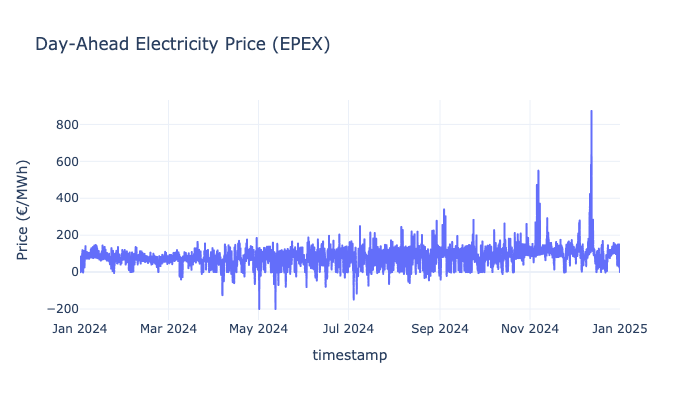

In [8]:
# Inspect day-ahead prices as an operational input.
# Load and resolve the price series.
prices_dataset = target_provider.get_prices()
prices_df = prices_dataset.select_version().data
print(f"Price columns: {list(prices_df.columns)}")

# Plot the day-ahead price signal.
fig = px.line(
    prices_df,
    title="Day-Ahead Electricity Price (EPEX)",
    labels={"value": "Price (€/MWh)", "index": "Time (UTC)", "variable": ""},
    template="plotly_white",
)
fig.update_layout(height=400, showlegend=False)
fig.show()

## Step 3 - Train a Default XGBoost Model

### 3.1 Training Window and Model Setup

We now compose the aligned input datasets and choose one training and forecast period. XGBoost captures non-linear feature interactions well, but tree-based models do not extrapolate beyond values represented in training data.


- **Q3.1.1** Which patterns should trees capture well in a solar park?
- **Q3.1.2** Where might a tree-based model struggle, especially near unseen peaks?
- **Q3.1.3** What evidence would distinguish a model limitation from a bad input feature?

In [9]:
from openstef_core.datasets import VersionedTimeSeriesDataset
from openstef_core.types import AvailableAt, LeadTime, Q, Quantile
from openstef_models.presets import ForecastingWorkflowConfig, create_forecasting_workflow

# Align all target inputs on one resolved time series.
combined_dataset = VersionedTimeSeriesDataset.concat(
    [load_dataset, weather_dataset, prices_dataset, profiles_dataset],
    mode="left",
).select_version()

TRAIN_START = datetime.fromisoformat("2024-02-01T00:00:00Z")
TRAIN_END = datetime.fromisoformat("2024-05-12T00:00:00Z")
FORECAST_START = TRAIN_END
FORECAST_HORIZON = LeadTime.from_string("P7D")
FORECAST_END = FORECAST_START + FORECAST_HORIZON.value

# Keep model history separate from the forecast-only series used in plots.
# Define the training, prediction-context, and visible forecast windows.
train_dataset = combined_dataset.filter_by_range(start=TRAIN_START, end=TRAIN_END)
predict_dataset = combined_dataset.filter_by_range(
    start=FORECAST_START - timedelta(days=14),
    end=FORECAST_END,
)
forecast_dataset = predict_dataset.filter_by_range(start=FORECAST_START, end=FORECAST_END)

# Use one quantile grid for every model comparison.
QUANTILES = [Q(0.05), Q(0.1), Q(0.3), Q(0.5), Q(0.7), Q(0.9), Q(0.95)]

# Report the selected windows and training shape.
print(f"Training: {TRAIN_START.date()} to {TRAIN_END.date()}")
print(f"Forecast: {FORECAST_START} to {FORECAST_END}")
print(f"Training features: {len(train_dataset.data.columns)} columns, {len(train_dataset.data):,} rows")

Training: 2024-02-01 to 2024-05-12
Forecast: 2024-05-12 00:00:00+00:00 to 2024-05-19 00:00:00+00:00
Training features: 28 columns, 9,696 rows


In [10]:
# Fit the default XGBoost workflow on the shared training window.
# Create the model configuration and feature mappings.
xgb_workflow = create_forecasting_workflow(
    config=ForecastingWorkflowConfig(
        model_id="demo_xgboost_default",
        model="xgboost",
        horizons=[FORECAST_HORIZON],
        quantiles=QUANTILES,
        target_column="load",
        radiation_column="shortwave_radiation",
        wind_speed_column="wind_speed_80m",
        pressure_column="surface_pressure",
        temperature_column="temperature_2m",
        relative_humidity_column="relative_humidity_2m",
        energy_price_column="EPEX_NL",
        rolling_aggregate_features=["mean", "median", "max", "min"],
        mlflow_storage=None,
        verbosity=0,
    )
)

# Fit XGBoost once on the prepared training data.
print("Training default XGBoost model...")
xgb_fit_result = xgb_workflow.fit(train_dataset)
print("Training complete.")

Training default XGBoost model...
Training complete.


### 3.2 Forecast Preview: Default XGBoost

The plot shows observed load, the median forecast, uncertainty bands, and target limits.


- **Q3.2.1** Where does the forecast track the measured signal, and where does it miss?
- **Q3.2.2** Are the uncertainty bands wider at moments where you expect more risk?
- **Q3.2.3** How often does the forecast cross an operational limit?
- **Q3.2.4** On this forecast day, could a production dip suggest self-curtailment, and what other signals would you inspect?

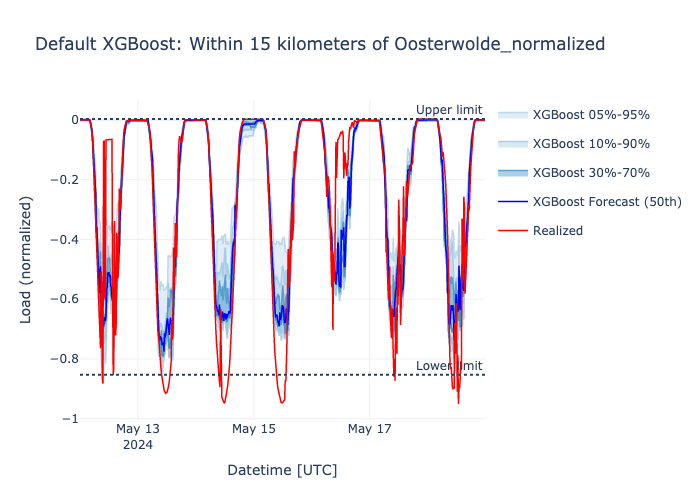

In [11]:
# Import the forecast dataset and plotting helper.
from openstef_beam.analysis.plots import ForecastTimeSeriesPlotter
from openstef_core.datasets import ForecastDataset

# Predict the complete horizon using the historical context window.
forecast_xgb_default: ForecastDataset = xgb_workflow.predict(
    predict_dataset,
    forecast_start=FORECAST_START,
)
# Plot only the requested forecast window; the model still receives its history above.
fig = (
    ForecastTimeSeriesPlotter()
    .add_measurements(measurements=forecast_dataset.data["load"])
    .add_model(
        model_name="XGBoost",
        forecast=forecast_xgb_default.median_series,
        quantiles=forecast_xgb_default.quantiles_data,
    )
    .add_limit(value=target.upper_limit, name="Upper limit")
    .add_limit(value=target.lower_limit, name="Lower limit")
    .plot(title=f"Default XGBoost: {TARGET_NAME}")
)
fig.update_layout(height=500, yaxis_title="Load (normalized)")
fig.show()

### 3.3 Explainability: Default XGBoost

Explainability connects a forecast back to the signals the model used. Global feature importance is a useful summary; per-timestep contributions show how those signals moved individual predictions.


- **Q3.3.1** Which features does the model find useful?
- **Q3.3.2** Do those features match your understanding of solar production and curtailment?
- **Q3.3.3** Which features push an individual forecast up or down?
- **Q3.3.4** What test would you run before trusting a highly important feature or contribution?

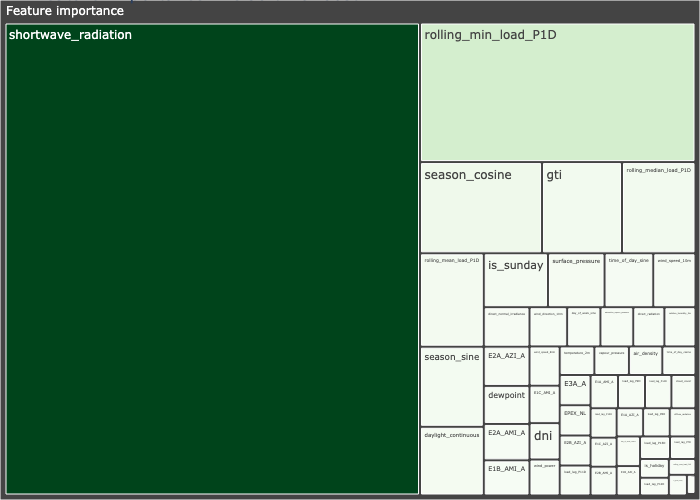

Contribution data: 672 rows x 74 columns


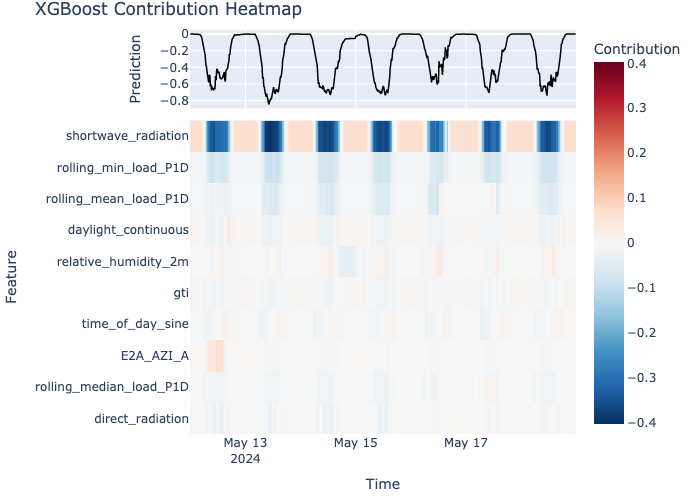

In [12]:
# Import the explainability interfaces used below.
from typing import cast

from openstef_models.explainability import ContributionsPlotter, ExplainableForecaster

explainable_xgb = cast(ExplainableForecaster, xgb_workflow.model.forecaster)
# Show both global importance and local per-timestep contributions.
# Plot the model-wide feature importance summary.
fig = explainable_xgb.plot_feature_importances()
fig.update_layout(title="Feature Importance: Default XGBoost", height=500)
fig.show()

# Calculate per-timestep feature contributions for the forecast context.
contributions = xgb_workflow.model.predict_contributions(predict_dataset, forecast_start=FORECAST_START)
print(f"Contribution data: {contributions.data.shape[0]:,} rows x {contributions.data.shape[1]} columns")
# Visualize the largest local contributions over time.
fig = ContributionsPlotter.plot_heatmap(contributions, top_n=10, show_prediction=True)
fig.update_layout(title="XGBoost Contribution Heatmap", height=500)
fig.show()

### 3.4 Inspect Derived Features

OpenSTEF's preprocessing pipeline derives features from raw data. The fitted result makes this modular step visible: selectors and feature adders prepare the input, a forecaster produces predictions, and postprocessing orders the quantiles.


- **Q3.4.1** Which columns are raw inputs and which were created by preprocessing?
- **Q3.4.2** Why do cyclic time features help represent daily or weekly behavior?
- **Q3.4.3** Which preprocessing step would you change first for another target type?

Derived features (75 total):
['load', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_speed_80m', 'wind_direction_10m', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'EPEX_NL', 'E1A_AZI_A', 'E1A_AMI_A', 'E1B_AZI_A', 'E1B_AMI_A', 'E1C_AZI_A', 'E1C_AMI_A', 'E2A_AZI_A', 'E2A_AMI_A', 'E2B_AZI_A', 'E2B_AMI_A', 'E3A_A', 'E3B_A', 'E3C_A', 'E3D_A', 'E4A_A', 'load_lag_P14D', 'load_lag_P13D', 'load_lag_P12D', 'load_lag_P11D', 'load_lag_P10D', 'load_lag_P9D', 'load_lag_P8D', 'load_lag_P7D', 'windspeed_hub_height', 'wind_power', 'saturation_vapour_pressure', 'vapour_pressure', 'dewpoint', 'air_density', 'dni', 'gti', 'season_sine', 'season_cosine', 'day_of_week_sine', 'day_of_week_cosine', 'month_sine', 'month_cosine', 'time_of_day_sine', 'time_of_day_cosine', 'daylight_continuous', 'rolling_mean_load_P1D', 'rolling_median_load_P1D', 'rolling_max_load_P1D', 'rolling_min_load_P1D', 'is_holiday', 'is_a

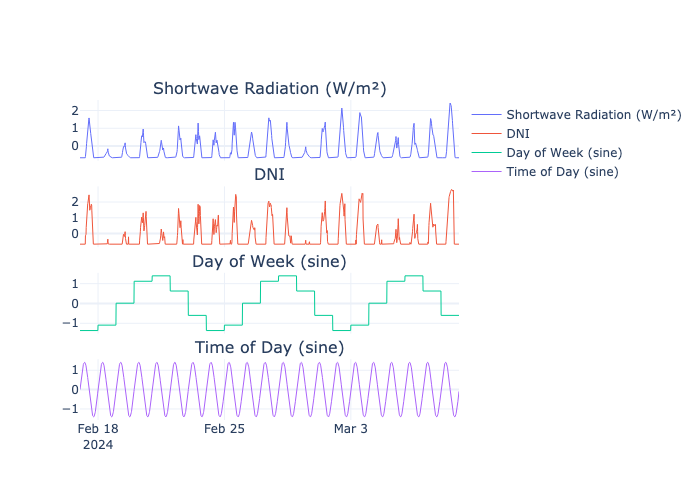

In [13]:
# Inspect the features generated by the fitted preprocessing pipeline.
# Read the transformed training data returned by the fit operation.
# Inspect the features generated by the fitted preprocessing pipeline.
# Read the transformed training data returned by the fit operation.
prepared_train = xgb_fit_result.input_data_train
derived_features = prepared_train.data
print(f"Derived features ({len(derived_features.columns)} total):")
print(list(derived_features.columns))

# Select a small set of interpretable derived features.
features_to_plot = [
    ("shortwave_radiation", "Shortwave Radiation (W/m²)"),
    ("dni", "DNI"),
    ("day_of_week_sine", "Day of Week (sine)"),
    ("time_of_day_sine", "Time of Day (sine)"),
]
window = derived_features.loc["2024-02-17":"2024-03-08"]
# Plot the selected preprocessing outputs together.
fig = make_subplots(
    rows=len(features_to_plot),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=[label for _, label in features_to_plot],
)
for row, (column, label) in enumerate(features_to_plot, start=1):
    if column in window.columns:
        fig.add_trace(
            go.Scatter(x=window.index, y=window[column], name=label, line={"width": 1}),
            row=row,
            col=1,
        )
fig.update_layout(height=500, template="plotly_white", showlegend=True)
fig.show()

## Step 4 - GBLinear and Modular Preprocessing

### 4.1 GBLinear Training

XGBoost trees cannot extrapolate beyond the training range. **GBLinear** is a gradient-boosted linear model that can extrapolate linearly, giving us a useful contrast with the tree baseline.

We keep sample weighting out of this first comparison so the model differences stay easy to interpret. The important workshop point is the shared workflow shape: a preset assembles preprocessing, a forecaster, and postprocessing from configuration.


- **Q4.1.1** Which behavior should GBLinear capture that XGBoost may miss?
- **Q4.1.2** What does the fitted input reveal about work done before the model sees a row?
- **Q4.1.3** Which part of the workflow would you replace for custom preprocessing?

In [14]:
# Fit GBLinear as a contrasting model with linear extrapolation behavior.
# Create the GBLinear workflow with the same inputs and quantiles.
gbl_workflow = create_forecasting_workflow(
    config=ForecastingWorkflowConfig(
        model_id="demo_gblinear",
        model="gblinear",
        horizons=[FORECAST_HORIZON],
        quantiles=QUANTILES,
        target_column="load",
        radiation_column="shortwave_radiation",
        wind_speed_column="wind_speed_80m",
        pressure_column="surface_pressure",
        temperature_column="temperature_2m",
        relative_humidity_column="relative_humidity_2m",
        energy_price_column="EPEX_NL",
        rolling_aggregate_features=["mean", "median", "max", "min"],
        mlflow_storage=None,
        verbosity=0,
    )
)

# Fit GBLinear on the shared training data.
print("Training GBLinear model...")
gbl_fit_result = gbl_workflow.fit(train_dataset)
print("Training complete.")

Training GBLinear model...
Training complete.


## Step 5 - Ensemble Learning: Learn Which Model to Trust

### 5.1 Ensemble Training

`openstef-meta` adds an ensemble workflow around the same forecasting components. The learned-weights combiner sees the base-model forecasts and learns which one to trust under different conditions.

Here the ensemble uses XGBoost and GBLinear. They share the common workflow configuration, while each model keeps its own forecasting behavior and model-specific preprocessing.


- **Q5.1.1** What does an ensemble add that simply averaging two forecasts would not?
- **Q5.1.2** When would you expect the ensemble to favor XGBoost, and when GBLinear?
- **Q5.1.3** What evidence would show that the combiner learned useful behavior instead of fitting noise?

In [15]:
# Fit the learned ensemble and generate its forecast for comparison.
# Define the two-model ensemble configuration.
from openstef_meta.presets import EnsembleForecastingWorkflowConfig, create_ensemble_forecasting_workflow

ensemble_config = EnsembleForecastingWorkflowConfig(
    model_id="demo_xgboost_gblinear_ensemble",
    ensemble_type="learned_weights",
    base_models=["xgboost", "gblinear"],
    combiner_model="lgbm",
    horizons=[FORECAST_HORIZON],
    quantiles=QUANTILES,
    target_column="load",
    radiation_column="shortwave_radiation",
    wind_speed_column="wind_speed_80m",
    pressure_column="surface_pressure",
    temperature_column="temperature_2m",
    relative_humidity_column="relative_humidity_2m",
    energy_price_column="EPEX_NL",
    mlflow_storage=None,
    verbosity=0,
)
# Fit the combiner and request its forecast.
ensemble_workflow = create_ensemble_forecasting_workflow(ensemble_config)
ensemble_fit_result = ensemble_workflow.fit(train_dataset)
ensemble_forecast: ForecastDataset = ensemble_workflow.predict(
    predict_dataset,
    forecast_start=FORECAST_START,
)
print(f"Base models: {list(ensemble_config.base_models)}")
print(f"Combiner: {ensemble_config.combiner_model}")
print(f"Forecast rows: {len(ensemble_forecast.data):,}")

[2026-09-10 17:00:54,159][WARNING] No aggregation functions specified. Skipping fit.
[2026-09-10 17:00:54,160][WARNING] No aggregation functions specified. Returning original data.
[2026-09-10 17:00:54,238][WARNING] No aggregation functions specified. Returning original data.
[2026-09-10 17:00:54,324][WARNING] No aggregation functions specified. Returning original data.


[0]	validation_0-mean_pinball_loss:0.20289	validation_1-mean_pinball_loss:0.19499
[1]	validation_0-mean_pinball_loss:0.16476	validation_1-mean_pinball_loss:0.16044
[2]	validation_0-mean_pinball_loss:0.13640	validation_1-mean_pinball_loss:0.13609
[3]	validation_0-mean_pinball_loss:0.11531	validation_1-mean_pinball_loss:0.12097
[4]	validation_0-mean_pinball_loss:0.09945	validation_1-mean_pinball_loss:0.11014
[5]	validation_0-mean_pinball_loss:0.08719	validation_1-mean_pinball_loss:0.10143
[6]	validation_0-mean_pinball_loss:0.07792	validation_1-mean_pinball_loss:0.09470
[7]	validation_0-mean_pinball_loss:0.07056	validation_1-mean_pinball_loss:0.09072
[8]	validation_0-mean_pinball_loss:0.06470	validation_1-mean_pinball_loss:0.08793
[9]	validation_0-mean_pinball_loss:0.06004	validation_1-mean_pinball_loss:0.08488
[10]	validation_0-mean_pinball_loss:0.05638	validation_1-mean_pinball_loss:0.08303
[11]	validation_0-mean_pinball_loss:0.05322	validation_1-mean_pinball_loss:0.08144
[12]	validatio

[2026-09-10 17:00:56,872][WARNING] No aggregation functions specified. Returning original data.


[LightGBM] [Info] Number of positive: 7898, number of negative: 454
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 508
[LightGBM] [Info] Number of data points in the train set: 8352, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.054358 -> initscore=-2.856268
[LightGBM] [Info] Start training from score -2.856268
[LightGBM] [Info] Number of positive: 7680, number of negative: 672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 509
[LightGBM] [Info] Number of data points in the train set: 8352, number of used features: 2
[LightGBM] [Info] [binary:Boos

[2026-09-10 17:01:02,451][WARNING] No aggregation functions specified. Returning original data.
[2026-09-10 17:01:02,517][WARNING] No aggregation functions specified. Returning original data.


Base models: ['xgboost', 'gblinear']
Combiner: lgbm
Forecast rows: 672


## Step 6 - Foundation Model Forecasting with Chronos-2

### 6.1 Chronos Forecasting

`openstef-foundation-models` adds Chronos-2, a pretrained foundation model for zero-shot probabilistic forecasting. It does not train on this target. Instead, it receives recent load history and known-future covariates, then produces a forecast through the same workflow interface.

We use the compact published checkpoint so the workshop stays practical on CPU. Chronos is kept as a separate model in this comparison because the current meta ensemble API accepts trainable base-model names only.


- **Q6.1.1** What is different about zero-shot forecasting compared with fitting XGBoost or GBLinear here?
- **Q6.1.2** Which information can Chronos use after the forecast origin, and which would be leakage?
- **Q6.1.3** Does the Chronos forecast look like a local model or a broad prior over time-series behavior?

In [16]:
# Run the zero-shot Chronos workflow with the same forecast horizon.
# Load the compact foundation-model checkpoint and workflow factory.
from openstef_foundation_models.models import Chronos2
from openstef_foundation_models.presets.forecasting_workflow import (
    ForecastingWorkflowConfig as FoundationForecastingWorkflowConfig,
)
from openstef_foundation_models.presets.forecasting_workflow import (
    create_forecasting_workflow as create_foundation_forecasting_workflow,
)
from openstef_models.utils.feature_selection import Include

# Configure Chronos with the target and known-future weather features.
chronos_config = FoundationForecastingWorkflowConfig(
    model="chronos2",
    checkpoint=Chronos2.SMALL.checkpoint(),
    quantiles=QUANTILES,
    horizons=[FORECAST_HORIZON],
    target_column="load",
    selected_features=Include(
        "load",
        "shortwave_radiation",
        "wind_speed_80m",
        "temperature_2m",
    ),
    model_id="demo_chronos2",
)
# Build the zero-shot workflow once.
chronos_workflow = create_foundation_forecasting_workflow(chronos_config)
chronos_window = combined_dataset.filter_by_range(
    start=FORECAST_START - timedelta(days=60),
    end=FORECAST_END,
)
# Generate the Chronos forecast.
chronos_forecast: ForecastDataset = chronos_workflow.predict(
    chronos_window,
    forecast_start=FORECAST_START,
)
print(f"Chronos model fitted: {chronos_workflow.model.is_fitted}")
print(f"Forecast rows: {len(chronos_forecast.data):,}")

[2026-09-10 17:01:04,261][INFO] DefaultProviderPolicy selected execution-provider chain ['CPUExecutionProvider'] for checkpoint 'chronos2' (precision=fp32, static_shapes=False) on darwin.
[2026-09-10 17:01:04,420][INFO] ONNX Runtime session built; realized providers: ['CPUExecutionProvider'].


Chronos model fitted: True
Forecast rows: 672


## Step 7 - Compare the Forecasts

### 7.1 Forecast Comparison

Compare the XGBoost, GBLinear, learned ensemble, and Chronos-2 p50 forecasts at the same forecast origin. The models share the target and operational context, but they learn in different ways.


- **Q7.1.1** Which model follows the actual signal most closely during this period?
- **Q7.1.2** Where do the models disagree, and what kind of uncertainty does that reveal?
- **Q7.1.3** Would you choose the best-looking median, the narrowest interval, or the most useful limit warnings?

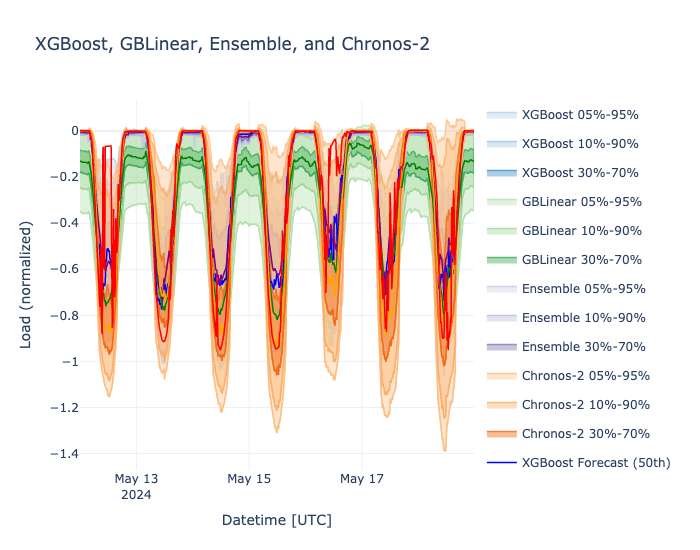

In [17]:
# Compare the models using only the forecast-window measurements.
# Generate classical-model forecasts from the shared prediction context.
# Compare the models using only the forecast-window measurements.
# Generate classical-model forecasts from the shared prediction context.
comparison_window = predict_dataset
xgb_comparison_forecast: ForecastDataset = xgb_workflow.predict(
    comparison_window,
    forecast_start=FORECAST_START,
)
gbl_comparison_forecast: ForecastDataset = gbl_workflow.predict(
    comparison_window,
    forecast_start=FORECAST_START,
)
# Overlay each model's p50 and uncertainty bands.
comparison_plotter = (
    ForecastTimeSeriesPlotter()
    .add_measurements(measurements=forecast_dataset.data["load"])
    .add_model(
        model_name="XGBoost",
        forecast=xgb_comparison_forecast.median_series,
        quantiles=xgb_comparison_forecast.quantiles_data,
    )
    .add_model(
        model_name="GBLinear",
        forecast=gbl_comparison_forecast.median_series,
        quantiles=gbl_comparison_forecast.quantiles_data,
    )
    .add_model(
        model_name="Ensemble",
        forecast=ensemble_forecast.median_series,
        quantiles=ensemble_forecast.quantiles_data,
    )
    .add_model(
        model_name="Chronos-2",
        forecast=chronos_forecast.median_series,
        quantiles=chronos_forecast.quantiles_data,
    )
)
fig = comparison_plotter.plot(title="XGBoost, GBLinear, Ensemble, and Chronos-2")
fig.update_layout(height=550, yaxis_title="Load (normalized)")
fig.show()

## Step 8 - Short Backtest with OpenSTEF BEAM

### 8.1 Backtest Configuration and Execution

One forecast plot builds intuition, but it does not tell us how a model behaves across repeated forecast origins. `openstef-beam` provides the backtesting and evaluation workflow. We keep the same target and shorten the benchmark period for a workshop run.

The short benchmark spans four weeks while keeping each forecast window at 7 days.

The benchmark is disabled by default so documentation builds stay fast. To run it locally,
set `RUN_BENCHMARK = True` in the setup cell below and execute the benchmark cells.


- **Q8.1.1** How would weekly retraining change the interpretation of the trainable-model results?
- **Q8.1.2** What should we check in the benchmark output before claiming one model is better?
- **Q8.1.3** Why must a backtest use the forecast version available at the time?

In [18]:
# Configure benchmark storage, model variants, and evaluation inputs.
# Import the benchmark runner, storage, and visualization components.
from openstef_beam.analysis import AnalysisConfig
from openstef_beam.analysis.visualizations import TimeSeriesVisualization
from openstef_beam.benchmarking.baselines.openstef4 import create_openstef4_preset_backtest_forecaster
from openstef_beam.benchmarking.benchmark_pipeline import BenchmarkContext, BenchmarkPipeline
from openstef_beam.benchmarking.benchmarks.liander2024 import (
    Liander2024Category,
    create_liander2024_benchmark_runner,
)
from openstef_beam.benchmarking.callbacks.strict_execution_callback import StrictExecutionCallback
from openstef_beam.benchmarking.models import BenchmarkTarget
from openstef_beam.benchmarking.storage.base import BenchmarkStorage
from openstef_beam.benchmarking.storage.local_storage import LocalBenchmarkStorage
from openstef_beam.evaluation import EvaluationConfig, Window
from openstef_foundation_models.integrations.beam import FoundationModelBacktestForecaster

# Set this to True when running the benchmark interactively.
RUN_BENCHMARK = False

# Define separate output locations for each model and the comparison.
OUTPUT_PATH = Path("./benchmark_results")
BENCHMARK_RESULTS_PATH_XGBOOST = OUTPUT_PATH / "XGBoost"
BENCHMARK_RESULTS_PATH_GBLINEAR = OUTPUT_PATH / "GBLinear"
BENCHMARK_RESULTS_PATH_CHRONOS = OUTPUT_PATH / "Chronos-2"

# Share the feature and horizon configuration across classical models.
common_config = ForecastingWorkflowConfig(
    model_id="benchmark_model_",
    run_name=None,
    model="flatliner",
    horizons=[FORECAST_HORIZON],
    quantiles=QUANTILES,
    model_reuse_enable=True,
    mlflow_storage=None,
    radiation_column="shortwave_radiation",
    wind_speed_column="wind_speed_80m",
    pressure_column="surface_pressure",
    temperature_column="temperature_2m",
    relative_humidity_column="relative_humidity_2m",
    energy_price_column="EPEX_NL",
    rolling_aggregate_features=["mean", "median", "max", "min"],
    verbosity=0,
)
xgboost_config = common_config.model_copy(update={"model": "xgboost"})
gblinear_config = common_config.model_copy(update={"model": "gblinear"})
# Force fresh benchmark artifacts when rerunning the workshop.
storage_xgboost = LocalBenchmarkStorage(base_path=BENCHMARK_RESULTS_PATH_XGBOOST, skip_when_existing=False)
storage_gblinear = LocalBenchmarkStorage(base_path=BENCHMARK_RESULTS_PATH_GBLINEAR, skip_when_existing=False)
storage_chronos = LocalBenchmarkStorage(base_path=BENCHMARK_RESULTS_PATH_CHRONOS, skip_when_existing=False)

# Restrict the benchmark to the workshop target and period.
class ShortBenchmarkTargetProvider(Liander2024TargetProvider):
    """One target with a short benchmark period for a fast workshop run."""

    target_name: str
    target_group: str

    def get_targets(self, filter_args: list[Liander2024Category] | None = None) -> list[BenchmarkTarget]:
        """Return the selected target with a shortened benchmark period."""
        targets = super().get_targets(filter_args)
        targets = [item for item in targets if item.name == self.target_name and item.group_name == self.target_group]
        for item in targets:
            item.benchmark_start = datetime.fromisoformat("2024-05-01T00:00:00Z")
            item.benchmark_end = datetime.fromisoformat("2024-05-29T23:59:59Z")
        return targets

single_target_provider = ShortBenchmarkTargetProvider(
    data_dir=DATASET_DIR,
    target_name=TARGET_NAME,
    target_group=TARGET_GROUP,
)
targets = single_target_provider.get_targets()
assert len(targets) == 1, f"Expected 1 target, got {len(targets)}"
print(f"Benchmarking: {targets[0].name}")
print(f"Short benchmark period: {targets[0].benchmark_start.date()} to {targets[0].benchmark_end.date()}")

# Evaluate one day at the selected day-ahead availability.
WORKSHOP_EVALUATION_CONFIG = EvaluationConfig(
    available_ats=[AvailableAt.from_string("D-1T06:00")],
    lead_times=[],
    windows=[Window(lag=timedelta(hours=0), size=timedelta(days=1))],
)
# Configure which visualizations and analysis should be included in the benchmark analysis
WORKSHOP_ANALYSIS_CONFIG = AnalysisConfig(
    visualization_providers=[
        TimeSeriesVisualization(name="time_series"),
        WindowedMetricVisualization(
            name="rMAE_windowed_1D",
            metric=("rMAE", Quantile(0.5)),
            window=Window(lag=timedelta(hours=0), size=timedelta(days=1)),
        ),
        WindowedMetricVisualization(
            name="rCRPS_windowed_1D",
            metric="rCRPS",
            window=Window(lag=timedelta(hours=0), size=timedelta(days=1)),
        ),
        GroupedTargetMetricVisualization(
            name="rMAE_grouped",
            metric="rMAE",
            quantile=Quantile(0.5),
        ),
        GroupedTargetMetricVisualization(
            name="rCRPS_grouped",
            metric="rCRPS",
        ),
        GroupedTargetMetricVisualization(
            name="rCRPS_sample_weighted_grouped",
            metric="rCRPS_sample_weighted",
        ),
        SummaryTableVisualization(
            name="summary",
        ),
        QuantileProbabilityVisualization(
            name="quantile_probability",
        ),
    ],
)


def create_workshop_benchmark_runner(
    storage: BenchmarkStorage,
) -> BenchmarkPipeline[BenchmarkTarget, list[Liander2024Category]]:
    """Create a runner with one-day evaluation metrics and all standard plots."""
    runner = create_liander2024_benchmark_runner(
        storage=storage,
        callbacks=[StrictExecutionCallback()],
        target_provider=single_target_provider,
    )
    runner.evaluation_config = WORKSHOP_EVALUATION_CONFIG
    runner.analysis_config = WORKSHOP_ANALYSIS_CONFIG
    return runner

Benchmarking: Within 15 kilometers of Oosterwolde_normalized
Short benchmark period: 2024-05-01 to 2024-05-29


In [19]:
# Run the classical-model backtests over the shortened benchmark period.
# Define a shared runner call for each trainable model.
def run_benchmark(
    storage: BenchmarkStorage,
    workflow_config: ForecastingWorkflowConfig,
    run_name: str,
) -> None:
    """Run one trainable workflow through the short BEAM benchmark."""
    create_workshop_benchmark_runner(storage).run(
        forecaster_factory=create_openstef4_preset_backtest_forecaster(
            workflow_config=workflow_config,
        ),
        run_name=run_name,
        n_processes=1,
    )

if RUN_BENCHMARK:
    run_benchmark(storage_xgboost, xgboost_config, "xgboost")
    run_benchmark(storage_gblinear, gblinear_config, "gblinear")

    # Adapt the loaded Chronos workflow to the BEAM backtest interface.
    def create_chronos_benchmark_forecaster(
        _context: BenchmarkContext,
        _target: BenchmarkTarget,
    ) -> FoundationModelBacktestForecaster:
        """Reuse the 7-day Chronos workflow across the benchmark windows."""
        # Reuse the loaded Chronos workflow for each backtest origin.
        return FoundationModelBacktestForecaster.from_workflow(
            chronos_workflow,
            predict_length=FORECAST_HORIZON.value,
            predict_context_length=timedelta(days=60),
        )

    create_workshop_benchmark_runner(storage_chronos).run(
        forecaster_factory=create_chronos_benchmark_forecaster,
        run_name="chronos2",
        n_processes=1,
    )
    print("All three short backtests complete.")
else:
    print("Benchmark skipped. Set RUN_BENCHMARK = True to run it locally.")

Benchmark skipped. Set RUN_BENCHMARK = True to run it locally.


## Step 9 - Compare Backtest Results

### 9.1 Metrics and Reports

`BenchmarkComparisonPipeline` turns stored BEAM runs into standardized reports with time-series views, grouped metrics, summary tables, and operational limit analysis.


- **Q9.1.1** In `summary.html`, which model has the lowest rMAE and rCRPS? Are they the same model?
- **Q9.1.2** In `rMAE_windowed_1D.html`, does the ranking stay stable through the benchmark period?
- **Q9.1.3** Does the output structure make the result easy to reproduce and audit?

In [20]:
# Generate the comparison reports for all completed benchmark runs.
# Import the report comparison pipeline.
from openstef_beam.benchmarking import BenchmarkComparisonPipeline

# Configure the output location and target scope.
COMPARISON_RESULT_PATH = OUTPUT_PATH / "comparison"
if RUN_BENCHMARK:
    comparison_pipeline = BenchmarkComparisonPipeline(
        analysis_config=WORKSHOP_ANALYSIS_CONFIG,
        storage=LocalBenchmarkStorage(base_path=COMPARISON_RESULT_PATH, skip_when_existing=False),
        target_provider=single_target_provider,
    )
    # Combine all model runs into the workshop reports.
    comparison_pipeline.run(
        run_data={
            "xgboost": storage_xgboost,
            "gblinear": storage_gblinear,
            "chronos2": storage_chronos,
        }
    )
    print(f"Results saved to: {COMPARISON_RESULT_PATH.resolve()}")
else:
    print("Comparison skipped because RUN_BENCHMARK is False.")

Comparison skipped because RUN_BENCHMARK is False.


## Step 10 - Workshop Summary

### 10.1 Questions to Close With

This workshop followed one target through OpenSTEF's modular forecasting stack:

1. Explored target measurements, versioned weather, profiles, and prices
2. Trained and explained XGBoost
3. Inspected preprocessing and derived features
4. Trained GBLinear as a contrasting extrapolating model
5. Built an ensemble with `openstef-meta`
6. Forecast with Chronos-2 through `openstef-foundation-models`
7. Backtested XGBoost, GBLinear, and Chronos-2 with `openstef-beam`

The conclusion should be supported by the forecast plot and the BEAM reports for this target and period.

- **Q10.1.1** Which model would you deploy for this target, and which evidence supports that choice?
- **Q10.1.2** What would you change first for a second target: data selection, preprocessing, model, or benchmark period?
- **Q10.1.3** Which OpenSTEF package owns each capability, and how does the modular setup make that boundary visible?

#### Output Structure

```text
benchmark_results/
├── XGBoost/
├── GBLinear/
├── Chronos-2/
└── comparison/
    └── global/D-1T0600/
        ├── rCRPS_windowed_1D.html
        ├── rMAE_grouped.html
        └── summary.html
```